In [ ]:
import sys, os
# Adjust depth based on notebook location relative to project root
_src_path = os.path.normpath(os.path.join(os.getcwd(), '..', '..', 'src'))
if _src_path not in sys.path:
    sys.path.insert(0, _src_path)
from project_config import load_config

config    = load_config()
base_dir  = config['base_dir']
well_list = config['well_list']
well_meta = config.get('well_metadata', {})

print(f'Active experiment: {config.get("experiment_name", config.get("experiment_key", "?"))}')
print(f'Base dir: {base_dir}')

In [ ]:
import pandas as pd
import numpy as np
import os
import matplotlib.pyplot as plt
import seaborn as sns
import anndata
from scipy.stats import scoreatpercentile
from sklearn.preprocessing import StandardScaler
import scipy.stats as stats

In [ ]:
def standardize(x =  None):
    """Standardizes data by removing the mean and scaling to unit variance.

    Parameters
    x: pd.DataFrame (default = None)
        data matrix (dimensions = cells x features)
    ----------

    Returns
    X: pd.DataFrame
        standardized data matrix (dimensions = cells x features)
    ----------
    """
    scaler = StandardScaler(with_mean = True, with_std = True)
    X = pd.DataFrame(scaler.fit_transform(x), index = x.index, columns = x.columns)
    return X

def pRB_cutoff(x_vec = None,
            pct = 50,
            filename_save = None):
    """Finds the cuttoff between arrested from cycling cells using the distribution of pRB expression
    Parameters
    x_vec: np.ndarray (default = None)
        array containing pRB expression values
    pct: int (default = 50)
        percentile for the one-sided distribution
    filename_save: str (default = None)
        str specifying filename for saving
    ----------

    Returns
    cut: float 
        cutpoint from the pRB/RB distribution separating pRB high (proliferative) from pRB low (arrested) cells
    ----------
    """
    med = np.median(x_vec)
    x_one_sided = x_vec.copy()              
    # fold over to the right all values left of the median
    x_one_sided[x_vec < med] = 2*med - x_vec[x_vec < med]

    # find the percentile of the one-sided distribution
    a = scoreatpercentile(x_one_sided, pct) - med

    #check how many elements fall into the range
    sel = (x_vec > (med - a)) & (x_vec < (med + a))

    cut = (np.sum(sel) / float(len(x_vec))) #cutpoint

    #look at histograms
    pd.DataFrame(x_vec).plot(kind='hist', bins=50, range=[-2, 5], legend=None) #un normalized data
    plt.tick_params(labelsize=14)
    plt.axvline(x=cut, ymin=0, ymax=3, color='red')
    plt.xlabel('standardized pRB/RB expression', fontsize=16)
    plt.ylabel('frequency', fontsize=16)
    if filename_save is not None:
        plt.savefig(filename_save+'.pdf', bbox_inches = 'tight')

    return cut

def preprocess(directory, filename_list, percentile, di_dose, di_condition, cell_id, prb_save_id):


    data = pd.DataFrame()
    for i in filename_list:
        data_ = pd.read_csv(os.path.join(directory, i + '.csv'), index_col = 0)
        data = pd.concat([data, data_], axis = 0)

    data.index = [cell_id + str(i) for i in range(0, data.shape[0])]
    data = data.loc[:, ['00_Rb_nuc_median', '00_pRB_nuc_median', '00_CDK2_nuc_median', 'well']].copy()
    data['pRB_over_RB'] = data['00_pRB_nuc_median'] / data['00_Rb_nuc_median']

    data['dose'] = data['well'].astype('|S').replace(di_dose)

    data['dose'] = data['well'].astype('|S').replace(di_dose)
    data['condition'] = data['well'].astype('|S').replace(di_condition)
    metadata = data.loc[:, ['well', 'condition', 'dose']]
    data.drop(columns = ['well', 'condition', 'dose'], inplace = True)

    #standardize 
    data_std = standardize(data)

    # # #create preprocessed annotated data object
    adata = anndata.AnnData(data_std)
    adata.obs = metadata.copy()
    adata.obs_names = adata.obs_names.astype('str')

    cut = pRB_cutoff(np.asarray(data_std.loc[:, 'pRB_over_RB']), percentile, prb_save_id)
    adata.obs['prb_ratio'] = np.nan
    adata.obs['prb_ratio'].values[data_std['pRB_over_RB'] >= cut] = 1
    adata.obs['prb_ratio'].values[data_std['pRB_over_RB'] < cut] = 0

    return adata

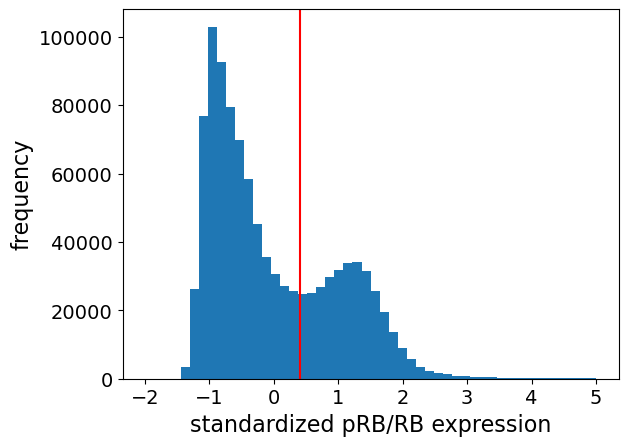

In [3]:
percentile = 40
cell_id = 'c_'
prb_save_id = 'CDK2_exp_pRB_RB'

di_dose = {b'B03':0.001, b'B04':0.01, b'B05':0.1, b'B06': 0.5, b'B07': 1, b'B08':2, b'B09':5, b'B10':10,
            b'C03':0.001, b'C04':0.01, b'C05':0.1, b'C06': 0.5, b'C07': 1, b'C08':2, b'C09':5, b'C10':10,
            b'D03':0.001, b'D04':0.01, b'D05':0.1, b'D06': 0.5, b'D07': 1, b'D08':2, b'D09':5, b'D10':10,
            b'E03':0.001, b'E04':0.01, b'E05':0.1, b'E06': 0.5, b'E07': 1, b'E08':2, b'E09':5,
            b'F03':0.001, b'F04':0.01, b'F05':0.1, b'F06': 0.5, b'F07': 1, b'F08':2, b'F09':5, b'F10':10,
            b'G03':0.001, b'G04':0.01, b'G05':0.1, b'G06': 0.5, b'G07': 1, b'G08':2, b'G09':5, b'G10':10}

di_condition = {b'B03':'untreated', b'B04':'untreated', b'B05':'untreated', b'B06': 'untreated', b'B07': 'untreated', b'B08':'untreated', b'B09':'untreated', b'B10':'untreated',
                b'C03':'untreated', b'C04':'untreated', b'C05':'untreated', b'C06': 'untreated', b'C07': 'untreated', b'C08':'untreated', b'C09':'untreated', b'C10':'untreated',
                b'D03':'palbociclib 50nM', b'D04':'palbociclib 50nM', b'D05':'palbociclib 50nM', b'D06': 'palbociclib 50nM', b'D07': 'palbociclib 50nM', b'D08':'palbociclib 50nM', b'D09':'palbociclib 50nM', b'D10':'palbociclib 50nM',
                b'E03':'palbociclib 50nM', b'E04':'palbociclib 50nM', b'E05':'palbociclib 50nM', b'E06': 'palbociclib 50nM', b'E07': 'palbociclib 50nM', b'E08':'palbociclib 50nM', b'E09':'palbociclib 50nM',
                b'F03':'palbociclib 10nM', b'F04':'palbociclib 10nM', b'F05':'palbociclib 10nM', b'F06': 'palbociclib 10nM', b'F07': 'palbociclib 10nM', b'F08':'palbociclib 10nM', b'F09':'palbociclib 10nM', b'F10':'palbociclib 10nM',
                b'G03':'palbociclib 10nM', b'G04':'palbociclib 10nM', b'G05':'palbociclib 10nM', b'G06': 'palbociclib 10nM', b'G07': 'palbociclib 10nM', b'G08':'palbociclib 10nM', b'G09':'palbociclib 10nM', b'G10':'palbociclib 10nM'}

directory = os.path.join('T47D-WT_3i_CTX313+Palbo_Sept2023', '06_Cell_Properties')
filename_list = [f'cell_data_B0{i}_df' if i < 10 else f'cell_data_B{i}_df' for i in range(3, 11)] + [f'cell_data_C0{i}_df' if i < 10 else f'cell_data_C{i}_df' for i in range(3, 11)] + [f'cell_data_D0{i}_df' if i < 10 else f'cell_data_D{i}_df' for i in range(3, 11)] + [f'cell_data_E0{i}_df' for i in range(3, 10)] + [f'cell_data_F0{i}_df' if i < 10 else f'cell_data_F{i}_df' for i in range(3, 11)] + [f'cell_data_G0{i}_df' if i < 10 else f'cell_data_G{i}_df' for i in range(3, 11)] 

adata = preprocess(directory, filename_list, percentile, di_dose, di_condition, cell_id, prb_save_id)

In [4]:
def set_means(df, well_list, id):
    df_run = df.copy()
    mean_val = (df_run[df_run.index.str.contains(id)][('prb_ratio', 'mean')][well_list[0]] + df_run[df_run.index.str.contains(id)][('prb_ratio', 'mean')][well_list[1]] + df_run[df_run.index.str.contains(id)][('prb_ratio', 'mean')][well_list[2]])/3
    df_run.at[well_list[0 ], 'prb_ratio'] = mean_val
    df_run.at[well_list[1], 'prb_ratio'] = mean_val
    df_run.at[well_list[2], 'prb_ratio'] = mean_val

    return df_run

def compute_means(df, well_list, id):
    df_run = df.copy()
    mean_val = (df_run[df_run.index.str.contains(id)]['prb_ratio'][well_list[0]] + df_run[df_run.index.str.contains(id)]['prb_ratio'][well_list[1]] + df_run[df_run.index.str.contains(id)]['prb_ratio'][well_list[2]])/3
    return mean_val

In [5]:
proportion_pos = adata.obs.groupby([ 'condition', 'dose', 'well']).describe()[('prb_ratio',  'mean')].copy()
proportion_pos = proportion_pos.reset_index(level=[0,1])
proportion_pos['run'] = '0'
proportion_pos.columns = proportion_pos.columns.droplevel(1)

df_arr = []
for well in ['B', 'C', 'D', 'E', 'F', 'G']:
    df_arr.append(proportion_pos[proportion_pos.index.str.contains(well)]['prb_ratio'] / proportion_pos.loc[well+'03', 'prb_ratio'])
df = pd.concat(df_arr, axis = 0)
df = pd.DataFrame(df.values, columns = ['normalized_pRB_ratio'], index = df.index)
proportion_pos = proportion_pos.merge(df, on = 'well', how = 'left')


df_arr = []
mean_val_list = []
for well in ['B', 'C', 'D', 'E', 'F', 'G']:
    mean_val = compute_means(proportion_pos, [well+'03', well+'04', well+'05'], well)
    mean_val_list.append(mean_val)
    df_arr.append(proportion_pos[proportion_pos.index.str.contains(well)]['prb_ratio'] / mean_val)
df = pd.concat(df_arr, axis = 0)
df = pd.DataFrame(df.values, columns = ['normalized_pRB_ratio_3rd'], index = df.index)
proportion_pos = proportion_pos.merge(df, on = 'well', how = 'left')


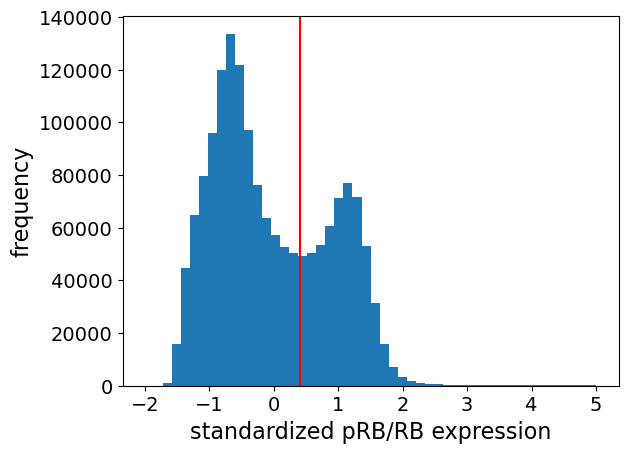

In [6]:
percentile = 40
cell_id = 'repeat_c'
prb_save_id = 'CDK2_exp_pRB_RB_repeat'

di_dose = {b'B02':0.001, b'B03':0.01, b'B04':0.1, b'B05': 0.5, b'B06': 1, b'B07':2, b'B08':5, b'B09':7.5, b'B10':10, b'B11':20,
            b'C02':0.001, b'C03':0.01, b'C04':0.1, b'C05': 0.5, b'C06': 1, b'C07':2, b'C08':5, b'C09':7.5, b'C10':10, b'C11':20,  
            b'D02':0.001, b'D03':0.01, b'D04':0.1, b'D05': 0.5, b'D06': 1, b'D07':2, b'D08':5, b'D09':7.5, b'D10':10, b'D11':20,
            b'E02':0.001, b'E03':0.01, b'E04':0.1, b'E05': 0.5, b'E06': 1, b'E07':2, b'E08':5, b'E09':7.5, b'E10':10, b'E11':20,
            b'F02':0.001, b'F03':0.01, b'F04':0.1, b'F05': 0.5, b'F06': 1, b'F07':2, b'F08':5, b'F09':7.5, b'F10':10, b'F11':20,
            b'G02':0.001, b'G03':0.01, b'G04':0.1, b'G05': 0.5, b'G06': 1, b'G07':2, b'G08':5, b'G09':7.5, b'G10':10, b'G11':20}

di_condition = {b'B02':'untreated', b'B03':'untreated', b'B04':'untreated', b'B05':'untreated', b'B06': 'untreated', b'B07': 'untreated', b'B08':'untreated', b'B09':'untreated', b'B10':'untreated', b'B11':'untreated',
                b'C02':'untreated', b'C03':'untreated', b'C04':'untreated', b'C05':'untreated', b'C06': 'untreated', b'C07': 'untreated', b'C08':'untreated', b'C09':'untreated', b'C10':'untreated', b'C11':'untreated',
                b'D02':'palbociclib 10nM', b'D03':'palbociclib 10nM', b'D04':'palbociclib 10nM', b'D05':'palbociclib 10nM', b'D06': 'palbociclib 10nM', b'D07': 'palbociclib 10nM', b'D08':'palbociclib 10nM', b'D09':'palbociclib 10nM', b'D10':'palbociclib 10nM', b'D11':'palbociclib 10nM',
                b'E02':'palbociclib 10nM', b'E03':'palbociclib 10nM', b'E04':'palbociclib 10nM', b'E05':'palbociclib 10nM', b'E06': 'palbociclib 10nM', b'E07': 'palbociclib 10nM', b'E08':'palbociclib 10nM', b'E09':'palbociclib 10nM', b'E10':'palbociclib 10nM', b'E11':'palbociclib 10nM',
                b'F02':'palbociclib 50nM', b'F03':'palbociclib 50nM', b'F04':'palbociclib 50nM', b'F05':'palbociclib 50nM', b'F06': 'palbociclib 50nM', b'F07': 'palbociclib 50nM', b'F08':'palbociclib 50nM', b'F09':'palbociclib 50nM', b'F10':'palbociclib 50nM', b'F11':'palbociclib 50nM',
                b'G02':'palbociclib 50nM', b'G03':'palbociclib 50nM', b'G04':'palbociclib 50nM', b'G05':'palbociclib 50nM', b'G06': 'palbociclib 50nM', b'G07': 'palbociclib 50nM', b'G08':'palbociclib 50nM', b'G09':'palbociclib 50nM', b'G10':'palbociclib 50nM', b'G11':'palbociclib 50nM'}

directory = os.path.join('T47D-WT_3i_CVT313+Palbo_Repeat_Sept2023', '06_Cell_Properties')
filename_list = [f'cell_data_B0{i}_df' if i < 10 else f'cell_data_B{i}_df' for i in range(2, 12)] + [f'cell_data_C0{i}_df' if i < 10 else f'cell_data_C{i}_df' for i in range(2, 12)] + [f'cell_data_D0{i}_df' if i < 10 else f'cell_data_D{i}_df' for i in range(2, 12)] + [f'cell_data_E0{i}_df' if i < 10 else f'cell_data_E{i}_df' for i in range(2, 12)] + [f'cell_data_F0{i}_df' if i < 10 else f'cell_data_F{i}_df' for i in range(2, 12)] + [f'cell_data_G0{i}_df' if i < 10 else f'cell_data_G{i}_df' for i in range(2, 12)] 

adata_repeat = preprocess(directory, filename_list, percentile, di_dose, di_condition, cell_id, prb_save_id)

In [7]:
proportion_pos_repeat = adata_repeat.obs.groupby([ 'condition', 'dose', 'well']).describe()[('prb_ratio',  'mean')].copy()
proportion_pos_repeat = proportion_pos_repeat.reset_index(level=[0,1])
proportion_pos_repeat['run'] = '1'
proportion_pos_repeat.columns = proportion_pos_repeat.columns.droplevel(1)

df_arr = []
for well in ['B', 'C', 'D', 'E', 'F', 'G']:
    df_arr.append(proportion_pos_repeat[proportion_pos_repeat.index.str.contains(well)]['prb_ratio'] / proportion_pos_repeat.loc[well+'02', 'prb_ratio'])
df = pd.concat(df_arr, axis = 0)
df = pd.DataFrame(df.values, columns = ['normalized_pRB_ratio'], index = df.index)
proportion_pos_repeat = proportion_pos_repeat.merge(df, on = 'well', how = 'left')

df_arr = []
mean_val_list_repeat = []
for well in ['B', 'C', 'D', 'E', 'F', 'G']:
    mean_val = compute_means(proportion_pos_repeat, [well+'02', well+'03', well+'04'], well)
    mean_val_list_repeat.append(mean_val)
    df_arr.append(proportion_pos_repeat[proportion_pos_repeat.index.str.contains(well)]['prb_ratio'] / mean_val)
df = pd.concat(df_arr, axis = 0)
df = pd.DataFrame(df.values, columns = ['normalized_pRB_ratio_3rd'], index = df.index)
proportion_pos_repeat = proportion_pos_repeat.merge(df, on = 'well', how = 'left')

In [8]:
proportion_pos_joint = pd.concat([proportion_pos, proportion_pos_repeat], axis = 0)

In [9]:
untreated_avg  = np.mean(mean_val_list[:2] + mean_val_list_repeat[:2])
palbo_10_avg  = np.mean(mean_val_list[4:6] + mean_val_list_repeat[2:4])
palbo_50_avg  = np.mean(mean_val_list[2:4] + mean_val_list_repeat[4:6])

In [13]:
colors_dict = {'untreated': '#B46CDA',
                'palbociclib 10nM': '#78CE8B',
                'palbociclib 50nM': '#FF8595'}

# colors_dict2 = {'untreated': 'k,
#                 'palbociclib 10nM': '#A554F5',
#                 'palbociclib 50nM': '#FF8595'}

save_directory = '/Volumes/purvislb/DATA_FOR_JOLENE'

/var/folders/kb/2tk0dg0x1jl0sdpds29dqln40000gn/T/ipykernel_12671/263628519.py:2: FutureWarning: 

The `ci` parameter is deprecated. Use `errorbar='sd'` for the same effect.

  g = sns.lineplot(x = 'dose', y = 'prb_ratio', data = proportion_pos_joint, hue = 'condition', marker = 'o',
/Users/jolene/miniconda3/envs/venv_tnbc/lib/python3.11/site-packages/seaborn/_oldcore.py:1498: FutureWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, CategoricalDtype) instead
  if pd.api.types.is_categorical_dtype(vector):
/Users/jolene/miniconda3/envs/venv_tnbc/lib/python3.11/site-packages/seaborn/_oldcore.py:1498: FutureWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, CategoricalDtype) instead
  if pd.api.types.is_categorical_dtype(vector):
/Users/jolene/miniconda3/envs/venv_tnbc/lib/python3.11/site-packages/seaborn/_oldcore.py:1498: FutureWarning: is_categorical_dtype is deprecated and wil

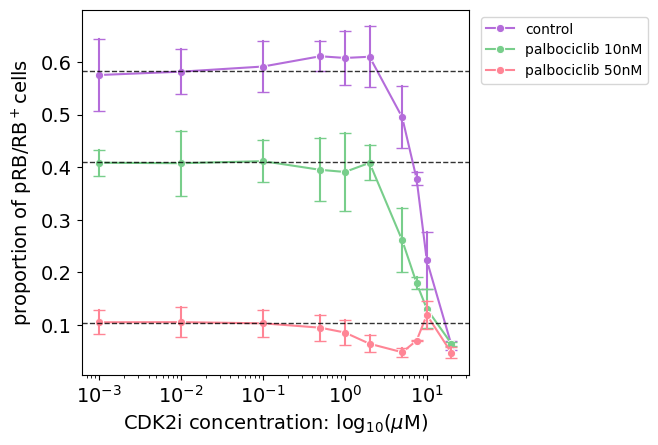

In [15]:
_, axes = plt.subplots(1, 1, figsize = (5, 5), gridspec_kw={'hspace': 0.45, 'wspace': 0.4, 'bottom':0.15})
g = sns.lineplot(x = 'dose', y = 'prb_ratio', data = proportion_pos_joint, hue = 'condition', marker = 'o',
                 ax = axes, hue_order = ['untreated', 'palbociclib 10nM', 'palbociclib 50nM'],
                 palette = colors_dict, estimator = 'mean', ci = 'sd', err_style='bars', err_kws = {'capsize': 4})

g.set(xscale='log')
plt.tick_params(labelsize=14)
g.set_ylabel('proportion of pRB/RB$^+$cells', fontsize = 14)
g.set_xlabel('CDK2i concentration: log$_{10}$($\mu$M)', fontsize = 14)
g.legend(['control', 'palbociclib 10nM', 'palbociclib 50nM'], bbox_to_anchor=(1.48,1), loc = 'upper right')
plt.axhline(untreated_avg, color = 'k', ls = '--', lw = 1, alpha = 0.8)
plt.axhline(palbo_10_avg, color = 'k', ls = '--', lw = 1, alpha = 0.8)
plt.axhline(palbo_50_avg, color = 'k', ls = '--', lw = 1, alpha = 0.8)
plt.savefig(os.path.join(save_directory, 'unnormalized_condition_average_4rep.pdf'), bbox_inches = 'tight')

/var/folders/kb/2tk0dg0x1jl0sdpds29dqln40000gn/T/ipykernel_12671/729995674.py:2: FutureWarning: 

The `ci` parameter is deprecated. Use `errorbar='sd'` for the same effect.

  g = sns.lineplot(x = 'dose', y = 'normalized_pRB_ratio_3rd',
/Users/jolene/miniconda3/envs/venv_tnbc/lib/python3.11/site-packages/seaborn/_oldcore.py:1498: FutureWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, CategoricalDtype) instead
  if pd.api.types.is_categorical_dtype(vector):
/Users/jolene/miniconda3/envs/venv_tnbc/lib/python3.11/site-packages/seaborn/_oldcore.py:1498: FutureWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, CategoricalDtype) instead
  if pd.api.types.is_categorical_dtype(vector):
/Users/jolene/miniconda3/envs/venv_tnbc/lib/python3.11/site-packages/seaborn/_oldcore.py:1498: FutureWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstanc

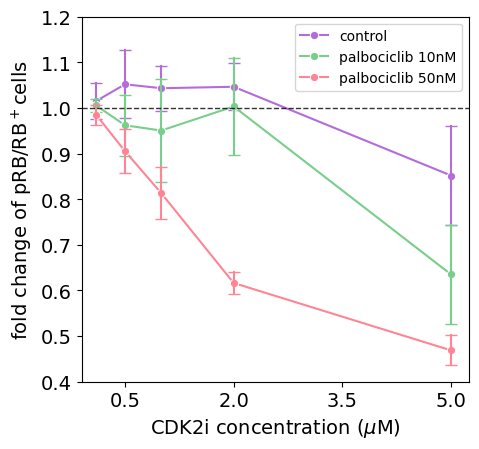

In [16]:
_, axes = plt.subplots(1, 1, figsize = (5, 5), gridspec_kw={'hspace': 0.45, 'wspace': 0.4, 'bottom':0.15})
g = sns.lineplot(x = 'dose', y = 'normalized_pRB_ratio_3rd',
                 data = proportion_pos_joint.iloc[np.where((proportion_pos_joint['dose'] >= 0.1) & (proportion_pos_joint['dose'] < 7.5))[0], :],
                 hue = 'condition', marker = 'o',
                 ax = axes, hue_order = ['untreated', 'palbociclib 10nM', 'palbociclib 50nM'],
                 palette = colors_dict, estimator = 'mean', ci = 'sd', err_style='bars', err_kws = {'capsize': 4})
g.set_xlim(-0.1, 5.25)
g.set_ylim(0.4, 1.2)
# g.set(xscale='log')
plt.tick_params(labelsize=14)
g.set_ylabel('fold change of pRB/RB$^+$cells', fontsize = 14)
g.set_xlabel('CDK2i concentration ($\mu$M)', fontsize = 14)
g.legend(['control', 'palbociclib 10nM', 'palbociclib 50nM'], loc = 'upper right')
plt.axhline(1.0, color = 'k', ls = '--', lw = 1, alpha = 0.8)
plt.xticks(np.arange(0.5, 6, 1.5))
plt.savefig(os.path.join(save_directory,'normalized_condition_average_4rep_avg3_smaller.pdf'), bbox_inches = 'tight')

In [23]:
proportion_pos_joint

,condition,dose,prb_ratio,run,normalized_pRB_ratio,normalized_pRB_ratio_3rd
well,,,,,,
F03,palbociclib 10nM,0.001,0.374951,0,1.000000,1.069564
G03,palbociclib 10nM,0.001,0.435197,0,1.000000,1.035648
F04,palbociclib 10nM,0.010,0.323674,0,0.863244,0.923295
G04,palbociclib 10nM,0.010,0.399670,0,0.918366,0.951104
F05,palbociclib 10nM,0.100,0.353068,0,0.941637,1.007141
...,...,...,...,...,...,...
C09,untreated,7.500,0.369034,1,0.723519,0.682927
B10,untreated,10.000,0.267012,1,0.490367,0.447819
C10,untreated,10.000,0.272389,1,0.534039,0.504077


In [33]:
100 - proportion_pos_joint[proportion_pos_joint['dose'] == 5.0].groupby('condition')['normalized_pRB_ratio_3rd'].mean()*100

condition
palbociclib 10nM    36.479028
palbociclib 50nM    53.121184
untreated           14.804420
Name: normalized_pRB_ratio_3rd, dtype: float64

In [34]:
proportion_pos_joint[proportion_pos_joint['dose'] == 5.0].groupby('condition')['normalized_pRB_ratio_3rd'].std()*100

condition
palbociclib 10nM    10.856066
palbociclib 50nM     3.259402
untreated           10.768581
Name: normalized_pRB_ratio_3rd, dtype: float64

In [ ]:
import scipy.stats as stats

# Group the DataFrame by dose
grouped = proportion_pos_joint.groupby("dose")

# Perform the Wilcoxon rank-sum test for each dose group
pval_untreated_10 = []
pval_untreated_50 = []
pval_10_50 = []
dose_list = []
for dose, group_data in grouped:
    dose_group_untreated = group_data[group_data["condition"] == "untreated"]["normalized_pRB_ratio_3rd"].values
    dose_group_10 = group_data[group_data["condition"] == "palbociclib 10nM"]["normalized_pRB_ratio_3rd"].values
    dose_group_50 = group_data[group_data["condition"] == "palbociclib 50nM"]["normalized_pRB_ratio_3rd"].values
    
    _, p_value = stats.ranksums(dose_group_untreated, dose_group_10)
    pval_untreated_10.append(p_value)
    _, p_value = stats.ranksums(dose_group_untreated, dose_group_50)
    pval_untreated_50.append(p_value)
    _, p_value = stats.ranksums(dose_group_10, dose_group_50)
    pval_10_50.append(p_value)
    dose_list.append(dose)

In [ ]:
pval_df = pd.DataFrame(index = dose_list)
pval_df['untreated_10nM_palbociclib'] = pval_untreated_10
pval_df['untreated_50nM_palbociclib'] = pval_untreated_50
pval_df['10nM_palbociclib_50nM_palbociclib'] = pval_10_50

In [ ]:
pval_df

In [ ]:
pval_df.to_csv(os.path.join(save_directory, 'pvalues.csv'))